# NIVARIA Gasifier — Step 1: Heater Power Identification

**Objective**: identify the net thermal power delivered by the three electric resistance heaters
(bottom, middle and top) from the wall temperature profiles measured during the pre-flow heating
phase (empty column, no biomass, no N₂ injection).

## Physical assumptions

- Empty column (no bed, no biomass)
- Static gas (no N₂ flow): the flow meter reads zero during the pre-flow phase
- Sensors TG_1 / TG_2 / TG_3 measure wall temperature (static gas equilibrates rapidly with the wall)
- **Three resistors**: one per zone — bottom (TG_1), middle (TG_2), top (TG_3)

## Simulation strategy

1. Load experimental data for cases with a valid pre-flow segment
2. Estimate initial power values analytically with `compute_bed_zone_power` (all three zones)
3. Simulate with HEATER (N=3, shell-tube, non-uniform `heatfluxwall`: `[Q_bottom, Q_middle, Q_top]`)
4. Fit Q_bottom, Q_middle and Q_top by minimising the RMSE against the measured wall temperatures

## Gasifier geometry

| Parameter | Value |
|-----------|-------|
| Length L | 0.75 m |
| Inner diameter Di | 80 mm |
| Outer diameter Do | 90 mm |
| Wall thickness | 5 mm |
| Wall material | Stainless steel SS316L |

## 1. Imports y configuración

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import interp1d

# ── Rutas ────────────────────────────────────────────────────────────────────
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
EXP  = os.getcwd()   # carpeta experimentacion/

for p in [ROOT, EXP]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── HEATER API ───────────────────────────────────────────────────────────────
from src.units.heater.config.gas_props  import build_gas_prop_config
from src.units.heater.config.boundary_c import build_boundary_c_config
from src.units.heater.config.thermal_bc import build_thermal_bc_config
from src.units.heater.config.transport  import build_transport_config
from src.units.heater.config.initial_c  import build_initial_c_config
from src.units.heater.config.wall_c     import build_wall_config
from src.units.heater.state             import pack_state_vector
from src.solvers.runner_heater          import run_step
from src.postprocessing.heater_balances import balance_report

# ── Datos experimentales ─────────────────────────────────────────────────────
from getDataHeater import (
    process_folder_for_empty_validation,
    build_empty_segments_for_cases,
    build_empty_segments_summary,
    build_pre_flow_segments_for_cases,
    build_pre_flow_summary,
    compute_bed_zone_power,
    plot_bed_zone_power,
)

DB_GAS   = os.path.join(ROOT, "materials", "fluids",  "gasdb.txt")
DB_SOLID = os.path.join(ROOT, "materials", "solids", "soliddb.txt")
RAW_DIR  = os.path.join(EXP, "rawData")

print("Imports OK")
print("gasdb   existe:", os.path.isfile(DB_GAS))
print("soliddb existe:", os.path.isfile(DB_SOLID))
print("rawData  existe:", os.path.isdir(RAW_DIR))

Imports OK
gasdb   existe: True
soliddb existe: True
rawData  existe: True


## 2. Carga de datos experimentales

In [2]:
# Lectura de todos los ensayos
cases_raw = process_folder_for_empty_validation(RAW_DIR, min_pre_feed_min=5.0)
cases_seg = build_empty_segments_for_cases(cases_raw)

# Detectar tramo pre-flow (sin caudal) para casos con columna vacía
cases_pf  = build_pre_flow_segments_for_cases(
    cases_seg,
    flow_candidates=["Temp_aire-Ten_QA_0", "Caudal_aire", "Temp_aire-Ten_QS_0"],
    flow_threshold=0.0,
)

summary_pf = build_pre_flow_summary(cases_pf)
print("Resumen de tramos pre-flow:")
print(summary_pf[["idx", "file_name", "ok_pre_flow", "duration_min"]].to_string(index=False))

Resumen de tramos pre-flow:
 idx                                            file_name  ok_pre_flow  duration_min
   0           20260112_NIVARIA_prueba_10 sin cribar.xlsx        False           NaN
   1           20260114_NIVARIA_prueba_10 sin cribar.xlsx         True      3.200000
   2           20260128_NIVARIA_prueba_15 sin cribar.xlsx         True     37.216667
   3           20260202_NIVARIA_prueba_15 sin cribar.xlsx         True     66.800000
   4           20260203_NIVARIA_prueba_20 sin cribar.xlsx         True      0.000000
   5           20260204_NIVARIA_prueba_20 sin cribar.xlsx         True      5.200000
   6              20260206_NIVARIA_prueba_10 cribado.xlsx         True      0.000000
   7             20260211_NIVARIA_prueba_ 15 cribado.xlsx         True     14.000000
   8             20260212_NIVARIA_prueba_ 15 cribado.xlsx         True      0.000000
   9             20260216_NIVARIA_prueba_ 20 cribado.xlsx         True      0.000000
  10             20260217_NIVARIA_pru

In [3]:
# ── Seleccionar el caso para ajuste ─────────────────────────────────────────
#
# Criterios de selección útiles:
#  1. ok_pre_flow=True  — tramo sin inyección de N₂ detectado
#  2. Duración ≥ MIN_DURATION_MIN — suficiente para ajustar la potencia
#
# Los casos identificados en el análisis previo (getDataEmpetyColumn) con
# columna vacía y sin inyección de gas son:
#   idx=2  →  20260128 prueba_15 sin cribar  (≈37 min)  ← más corto, primer ajuste
#   idx=3  →  20260202 prueba_15 sin cribar  (≈67 min)  ← más largo, validación cruzada
#   idx=11 →  20260219 prueba_15 sin cribar 500C (≈59 min) — ensayo a 500 °C
#
# Para usar un caso diferente: cambiar CASE_IDX y re-ejecutar desde aquí.

MIN_DURATION_MIN = 20.0   # [min] — umbral mínimo para que el ajuste tenga sentido

ok_pf = summary_pf[
    (summary_pf["ok_pre_flow"] == True) &
    (summary_pf["duration_min"] >= MIN_DURATION_MIN)
].copy().sort_values("duration_min").reset_index(drop=True)

print(f"Casos con tramo pre-flow ≥ {MIN_DURATION_MIN:.0f} min (sin biomasa y sin flujo de N₂):")
print(ok_pf[["idx", "file_name", "duration_min"]].to_string(index=False))

if ok_pf.empty:
    raise RuntimeError(
        f"No hay casos con tramo pre-flow ≥ {MIN_DURATION_MIN} min. "
        "Reducir MIN_DURATION_MIN o revisar los datos."
    )

# Por defecto: caso más corto entre los válidos (≈37 min, más manejable para primera iteración).
# Para el caso de 67 min:  CASE_IDX = 3
# Para el ensayo 500 °C:   CASE_IDX = 11
CASE_IDX = int(ok_pf.iloc[0]["idx"])

case = cases_pf[CASE_IDX]
seg  = case["pre_flow_segment"]

print(f"\nCaso seleccionado: [{CASE_IDX}] {case['file_name']}")
print(f"  Duración pre-flow : {seg['duration_min']:.2f} min")
print(f"  Inicio            : {seg['t_start_h']}   Fin: {seg['t_end_h']}")
print()
print("→ Para usar otro caso: CASE_IDX = <idx> y re-ejecutar desde esta celda.")

Casos con tramo pre-flow ≥ 20 min (sin biomasa y sin flujo de N₂):
 idx                                        file_name  duration_min
   2       20260128_NIVARIA_prueba_15 sin cribar.xlsx     37.216667
  11 20260219_NIVARIA_prueba_ 15 sin cribar_500C.xlsx     59.000000
   3       20260202_NIVARIA_prueba_15 sin cribar.xlsx     66.800000

Caso seleccionado: [2] 20260128_NIVARIA_prueba_15 sin cribar.xlsx
  Duración pre-flow : 37.22 min
  Inicio            : 10:29:23   Fin: 11:06:36

→ Para usar otro caso: CASE_IDX = <idx> y re-ejecutar desde esta celda.


Duración del tramo pre-flow: 37.22 min (2233 s)
Temperatura inicial media (estimada): 550.0 K (276.8 °C)
T final TG_1: 858.1 K   TG_2: 732.1 K   TG_3: 776.9 K


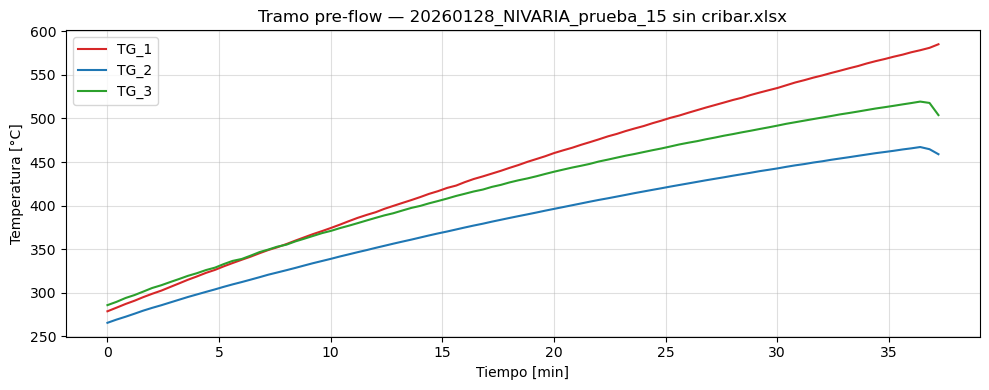

In [4]:
# ── Extraer perfil de temperatura experimental ───────────────────────────────
df_pf = case["dfs"]["process_pre_flow"].copy()

# Columnas de temperatura en °C → K
TEMP_COLS = {
    "TG_1": "Temp_aire-Ten_TG_1",   # sonda inferior  → celda 0
    "TG_2": "Temp_aire-Ten_TG_2",   # sonda media     → celda 1
    "TG_3": "Temp_aire-Ten_TG_3",   # sonda superior  → celda 2
}

# Verificar que las columnas existen
for label, col in TEMP_COLS.items():
    if col not in df_pf.columns:
        raise ValueError(f"Columna '{col}' no encontrada. Columnas disponibles: {list(df_pf.columns)}")

# Vector de tiempo relativo [s]
t_exp_s = df_pf["x_min"].values * 60.0   # min → s

# Temperaturas medidas en K
T_exp_K = {}
for label, col in TEMP_COLS.items():
    T_exp_K[label] = pd.to_numeric(df_pf[col], errors="coerce").values + 273.15

T_MAX_s   = float(t_exp_s[-1])      # duración total del tramo [s]
T_INIT_K  = float(np.nanmean([T_exp_K[k][0] for k in T_exp_K]))   # T inicial media [K]

print(f"Duración del tramo pre-flow: {T_MAX_s/60:.2f} min ({T_MAX_s:.0f} s)")
print(f"Temperatura inicial media (estimada): {T_INIT_K:.1f} K ({T_INIT_K - 273.15:.1f} °C)")
print(f"T final TG_1: {T_exp_K['TG_1'][-1]:.1f} K   TG_2: {T_exp_K['TG_2'][-1]:.1f} K   TG_3: {T_exp_K['TG_3'][-1]:.1f} K")

# Gráfica exploratoria
fig, ax = plt.subplots(figsize=(10, 4))
colors = {"TG_1": "#d62728", "TG_2": "#1f77b4", "TG_3": "#2ca02c"}
for label in ["TG_1", "TG_2", "TG_3"]:
    ax.plot(t_exp_s / 60.0, T_exp_K[label] - 273.15, label=label, color=colors[label])
ax.set_xlabel("Tiempo [min]")
ax.set_ylabel("Temperatura [°C]")
ax.set_title(f"Tramo pre-flow — {case['file_name']}")
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Estimación analítica de la potencia por zona

La potencia absorbida por cada zona de la pared se estima como:

$$\dot{Q}_{zona} = m_{pared,zona} \cdot c_p \cdot \frac{dT}{dt}$$

donde la derivada temporal se calcula con el filtro Savitzky-Golay sobre el perfil medido.

Esto asume que no hay flujo de gas (Q_gw ≈ 0) y que cada sonda representa la temperatura
media de una zona de longitud L/3 = 0.25 m.

Estimación analítica de potencia por zona:
  Q_zona_1 (inferior, TG_1) : +179.8 W
  Q_zona_2 (media,    TG_2) : +118.5 W
  Q_zona_3 (superior, TG_3) : +138.4 W
  Total estimado            : +436.7 W


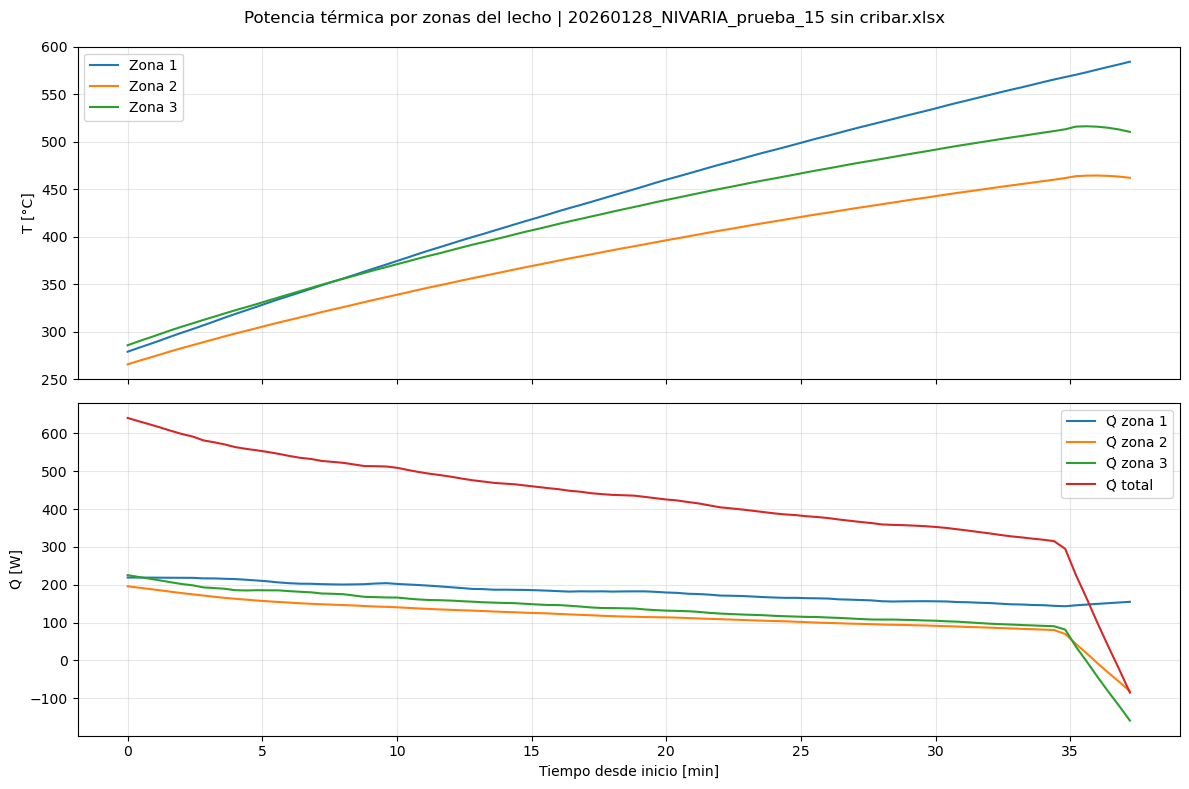

In [5]:
# Geometría del gasificador
L   = 0.75    # m
Di  = 0.08    # m
Do  = 0.09    # m
N   = 3       # celdas (una por zona de sonda)

ri  = Di / 2.0
ro  = Do / 2.0
dz  = L / N   # longitud de celda = 0.25 m

# Estimación analítica (zona_length = L/3)
zone_df = compute_bed_zone_power(
    case,
    data_key="process_pre_flow",
    temp_cols={
        "T_z1": "Temp_aire-Ten_TG_1",
        "T_z2": "Temp_aire-Ten_TG_2",
        "T_z3": "Temp_aire-Ten_TG_3",
    },
    L_m=L, ri_m=ri, ro_m=ro,
    rho_wall_kg_m3=7900.0,
    cp_wall_J_kg_K=500.0,
    zone_length_m=dz,     # 0.25 m por celda
    smooth_window=11,
    polyorder=2,
)

# Potencia media por zona en estado cuasi-estacionario
# (se excluye el transitorio inicial tomando el tramo medio del calentamiento)
frac_start, frac_end = 0.15, 0.85   # excluir 15% inicial y final
n = len(zone_df)
i0, i1 = int(n * frac_start), int(n * frac_end)

Q_est = {}
for key in ["z1", "z2", "z3"]:
    col = f"Qdot_{key}_W"
    Q_est[key] = float(np.nanmean(zone_df[col].iloc[i0:i1]))

print("Estimación analítica de potencia por zona:")
print(f"  Q_zona_1 (inferior, TG_1) : {Q_est['z1']:+.1f} W")
print(f"  Q_zona_2 (media,    TG_2) : {Q_est['z2']:+.1f} W")
print(f"  Q_zona_3 (superior, TG_3) : {Q_est['z3']:+.1f} W")
print(f"  Total estimado            : {sum(Q_est.values()):+.1f} W")

fig, axes = plot_bed_zone_power(zone_df, case_label=case["file_name"])
plt.tight_layout()
plt.show()

## 4. HEATER simulator setup

Shell-tube model with N=3 cells (one per sensor zone).
The gas (nearly static N₂) is initialised in thermal equilibrium with the wall.
Resistor power is applied as a per-cell vector `[Q_bottom, Q_middle, Q_top]`.

In [6]:
# ── Geometric and solver parameters ──────────────────────────────────────────
e_wall = (Do - Di) / 2.0
Ai     = 0.25 * np.pi * Di**2
Pi     = np.pi * Di
Po     = np.pi * Do

nc      = 1
SPECIES = ["N2"]
RTOL    = 1.0e-6
ATOL    = 1.0e-8
N_SEC   = 20       # output points per second (dense, for comparison with data)

# Initial wall and gas temperature [K] — mean of the 3 sensors at t=0
Tw_init_zones = np.array([
    float(np.nanmean(T_exp_K["TG_1"][:3])),
    float(np.nanmean(T_exp_K["TG_2"][:3])),
    float(np.nanmean(T_exp_K["TG_3"][:3])),
])
T_gas_init = float(np.mean(Tw_init_zones))   # gas in thermal equilibrium with wall at t=0

P_INIT  = 1.01325   # bar
V_IN    = 0.001     # m/s — virtually static gas (no real flow during pre-flow phase)

print("Simulator configuration:")
print(f"  N={N}  L={L} m  Di={Di*1e3:.0f} mm  Do={Do*1e3:.0f} mm  e={e_wall*1e3:.1f} mm")
print(f"  Tw_init zones [K]: {Tw_init_zones.round(1)}")
print(f"  T_gas_init [K]: {T_gas_init:.1f}")
print(f"  Simulation duration: {T_MAX_s/60:.2f} min")


def build_heater_params(
    Q_bottom: float,
    Q_middle: float,
    Q_top: float,
    Tw_init: np.ndarray = Tw_init_zones,
) -> tuple:
    """
    Build all configs and return (params, sv0).

    Q_bottom : power delivered by the bottom resistor [W] — cell 0 (TG_1 zone)
    Q_middle : power delivered by the middle resistor [W] — cell 1 (TG_2 zone)
    Q_top    : power delivered by the top    resistor [W] — cell 2 (TG_3 zone)
    """
    prop_gas = build_gas_prop_config(
        species=SPECIES, mode="polynomial", n_comp=nc, N=N, db_path=DB_GAS,
    )
    gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))

    bc = build_boundary_c_config(
        n_comp=nc, v_in=V_IN, T_in=T_gas_init,
        y_in=np.array([1.0]), P_out=P_INIT,
    )

    # Per-cell power vector [W]
    Q_cell = np.array([Q_bottom, Q_middle, Q_top], dtype=float)
    tbc = build_thermal_bc_config(
        mode="heatfluxwall", Di=Di, Do=Do, e_wall=e_wall,
        Qwall=Q_cell,
    )

    tc = build_transport_config(mode="correlation", N=N)

    wc = build_wall_config(
        N=N, Di=Di, Do=Do, T_w_init=Tw_init,
        material_id="SS316L", material_mode="polynomial", db_path=DB_SOLID,
    )

    ic = build_initial_c_config(
        P_init=P_INIT, Tg_init=T_gas_init, y_init=np.array([1.0]),
        n_comp=nc, N=N, prop_gas=prop_gas, gas_T_ref=gas_T_ref,
        wall_config=wc,
    )
    sv0 = pack_state_vector(ic["C_init"], ic["Hg_init"], Tw=ic["Tw_init"])

    params = {
        "n_comp":            nc,
        "N":                 N,
        "dz":                dz,
        "Ai":                Ai,
        "Di":                Di,
        "Pi":                Pi,
        "Po":                Po,
        "prop_gas":          prop_gas,
        "MW":                np.asarray(prop_gas["MW"]),
        "gas_T_ref":         gas_T_ref,
        "bc_config":         bc,
        "trans_config":      tc,
        "thermal_bc_config": tbc,
        "energy":            True,
        "prop_update_mode":  "always",
        "trans_update_mode": "always",
        "species":           SPECIES,
        "wall_config":       wc,
        "_cache":            {},
    }

    return params, sv0


print("\nbuild_heater_params defined OK")

Simulator configuration:
  N=3  L=0.75 m  Di=80 mm  Do=90 mm  e=5.0 mm
  Tw_init zones [K]: [556.2 542.4 563.1]
  T_gas_init [K]: 553.9
  Simulation duration: 37.22 min

build_heater_params defined OK


## 5. Simulación con la estimación analítica inicial

In [7]:
# Initial power estimate from analytical calculation (all three zones)
Q0_bottom = max(Q_est["z1"], 0.0)
Q0_middle = max(Q_est["z2"], 0.0)
Q0_top    = max(Q_est["z3"], 0.0)

print(f"Initial power estimate:  Q_bottom={Q0_bottom:.1f} W   Q_middle={Q0_middle:.1f} W   Q_top={Q0_top:.1f} W")

params0, sv0_0 = build_heater_params(Q0_bottom, Q0_middle, Q0_top)

t0_cpu = time.perf_counter()
t_arr0, _, h0 = run_step(
    sv0=sv0_0, t_max=T_MAX_s, params=params0,
    solver="solve_ivp", rtol=RTOL, atol=ATOL, n_sec=N_SEC,
)
cpu0 = time.perf_counter() - t0_cpu

print(f"Simulation completed in {cpu0:.2f} s CPU")
print(f"Tw final zones [K]: {h0._Tw_results[-1].round(1)}")
print(f"Tw final zones [°C]: {(h0._Tw_results[-1] - 273.15).round(1)}")

Initial power estimate:  Q_bottom=179.8 W   Q_middle=118.5 W   Q_top=138.4 W
Simulation completed in 40.26 s CPU
Tw final zones [K]: [827.7 742.3 775.7]
Tw final zones [°C]: [554.6 469.1 502.5]


Comparación con estimación analítica inicial:


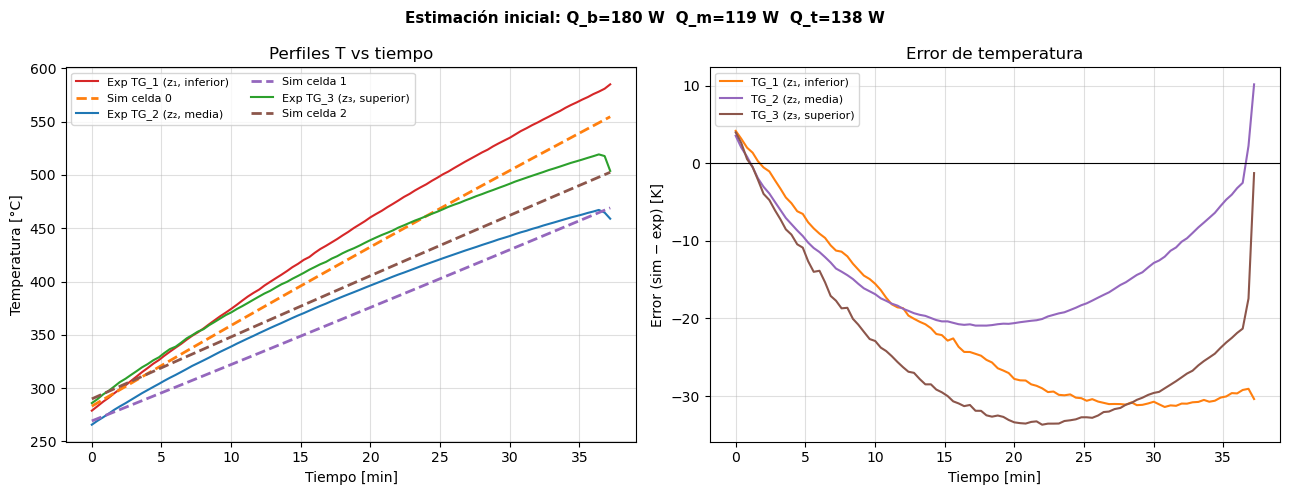

  RMSE zona 1 (TG_1): 24.04 K
  RMSE zona 2 (TG_2): 15.28 K
  RMSE zona 3 (TG_3): 26.08 K
  RMSE medio         : 21.80 K


In [8]:
def plot_comparison(h_sim, t_sim_s, title=""):
    """Compara perfil Tw simulado vs temperaturas medidas por zona."""
    labels  = ["TG_1 (z₁, inferior)", "TG_2 (z₂, media)", "TG_3 (z₃, superior)"]
    clr_exp = ["#d62728", "#1f77b4", "#2ca02c"]
    clr_sim = ["#ff7f0e", "#9467bd", "#8c564b"]
    tg_keys = ["TG_1", "TG_2", "TG_3"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    for i, (key, lbl) in enumerate(zip(tg_keys, labels)):
        ax.plot(t_exp_s / 60.0, T_exp_K[key] - 273.15,
                color=clr_exp[i], lw=1.5, label=f"Exp {lbl}")
        ax.plot(t_sim_s / 60.0, h_sim._Tw_results[:, i] - 273.15,
                color=clr_sim[i], lw=2.0, ls="--", label=f"Sim celda {i}")
    ax.set_xlabel("Tiempo [min]")
    ax.set_ylabel("Temperatura [°C]")
    ax.set_title("Perfiles T vs tiempo")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8, ncol=2)

    ax = axes[1]
    for i, (key, lbl, clr) in enumerate(zip(tg_keys, labels, clr_sim)):
        T_sim_interp = np.interp(t_exp_s, t_sim_s, h_sim._Tw_results[:, i])
        err_K = T_sim_interp - T_exp_K[key]
        valid = np.isfinite(err_K)
        ax.plot(t_exp_s[valid] / 60.0, err_K[valid], color=clr, lw=1.5, label=lbl)
    ax.axhline(0, color="k", lw=0.8, ls="-")
    ax.set_xlabel("Tiempo [min]")
    ax.set_ylabel("Error (sim − exp) [K]")
    ax.set_title("Error de temperatura")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)

    if title:
        fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

    rmse_per_zone = []
    for i, key in enumerate(tg_keys):
        T_sim_i = np.interp(t_exp_s, t_sim_s, h_sim._Tw_results[:, i])
        err = T_sim_i - T_exp_K[key]
        valid = np.isfinite(err)
        rmse = float(np.sqrt(np.mean(err[valid]**2)))
        rmse_per_zone.append(rmse)
        print(f"  RMSE zona {i+1} ({key}): {rmse:.2f} K")
    print(f"  RMSE medio         : {np.mean(rmse_per_zone):.2f} K")


print("Comparación con estimación analítica inicial:")
plot_comparison(h0, t_arr0,
    title=f"Estimación inicial: Q_b={Q0_bottom:.0f} W  Q_m={Q0_middle:.0f} W  Q_t={Q0_top:.0f} W")

## 6. Power optimisation

Minimise the root-mean-square error between simulated wall temperatures and measured
sensor values by adjusting the three free parameters `[Q_bottom, Q_middle, Q_top]`.

$$\min_{Q_b,\, Q_m,\, Q_t \ge 0} \; \text{RMSE}(T_w^{sim}, T^{exp})$$

Nelder-Mead is used (gradient-free, robust for noisy or non-smooth functions).

In [9]:
# Evaluation counter for progress logging
_eval_count = [0]


def objective(x):
    """Cost function: total RMSE between simulated Tw and measured temperatures.

    Parameters
    ----------
    x : array-like, shape (3,)
        [Q_bottom, Q_middle, Q_top] in W.
    """
    Q_b, Q_m, Q_t = float(x[0]), float(x[1]), float(x[2])

    # Non-negativity: exterior penalty (keeps Nelder-Mead in the feasible region)
    penalty = 0.0
    if Q_b < 0:
        penalty += 1e4 * Q_b**2
        Q_b = 0.0
    if Q_m < 0:
        penalty += 1e4 * Q_m**2
        Q_m = 0.0
    if Q_t < 0:
        penalty += 1e4 * Q_t**2
        Q_t = 0.0

    try:
        params, sv0 = build_heater_params(Q_b, Q_m, Q_t)
        t_sim, _, h = run_step(
            sv0=sv0, t_max=T_MAX_s, params=params,
            solver="solve_ivp", rtol=RTOL, atol=ATOL, n_sec=N_SEC,
        )
    except Exception as e:
        print(f"  ERROR en simulación: {e}")
        return 1e10

    tg_keys = ["TG_1", "TG_2", "TG_3"]
    sse   = 0.0
    n_pts = 0
    for i, key in enumerate(tg_keys):
        T_sim_i = np.interp(t_exp_s, t_sim, h._Tw_results[:, i])
        err     = T_sim_i - T_exp_K[key]
        valid   = np.isfinite(err)
        sse    += float(np.sum(err[valid]**2))
        n_pts  += int(np.sum(valid))

    rmse = float(np.sqrt(sse / max(n_pts, 1)))

    _eval_count[0] += 1
    if _eval_count[0] % 10 == 0:
        print(f"  Eval {_eval_count[0]:4d}: Q=[{Q_b:.1f}, {Q_m:.1f}, {Q_t:.1f}] W  →  RMSE={rmse:.3f} K")

    return rmse + penalty


print("Objective function defined.  Evaluating at initial estimate:")
_eval_count[0] = 0
rmse0 = objective([Q0_bottom, Q0_middle, Q0_top])
print(f"  RMSE with initial estimate: {rmse0:.3f} K")

Objective function defined.  Evaluating at initial estimate:
  RMSE with initial estimate: 22.297 K


In [10]:
print("Starting Nelder-Mead optimisation (3 free parameters)...")
print(f"  Initial point: Q_b={Q0_bottom:.1f} W   Q_m={Q0_middle:.1f} W   Q_t={Q0_top:.1f} W")
print()

_eval_count[0] = 0
t_opt_start = time.perf_counter()

result_opt = minimize(
    objective,
    x0=[Q0_bottom, Q0_middle, Q0_top],
    method="Nelder-Mead",
    options={
        "maxiter":  500,
        "xatol":    1.0,     # convergence tolerance in Q [W]
        "fatol":    0.05,    # convergence tolerance in RMSE [K]
        "disp":     True,
        "adaptive": True,
    },
)

t_opt_total = time.perf_counter() - t_opt_start

Q_opt_b, Q_opt_m, Q_opt_t = [max(v, 0.0) for v in result_opt.x]

print(f"\nOptimisation completed in {t_opt_total:.1f} s  ({_eval_count[0]} evaluations)")
print()
print("Optimal heater powers:")
print(f"  Q_bottom (cell 0, zone TG_1) = {Q_opt_b:.1f} W")
print(f"  Q_middle (cell 1, zone TG_2) = {Q_opt_m:.1f} W")
print(f"  Q_top    (cell 2, zone TG_3) = {Q_opt_t:.1f} W")
print(f"  Total                        = {Q_opt_b + Q_opt_m + Q_opt_t:.1f} W")
print()
print(f"Optimal RMSE: {result_opt.fun:.3f} K")

Starting Nelder-Mead optimisation (3 free parameters)...
  Initial point: Q_b=179.8 W   Q_m=118.5 W   Q_t=138.4 W

  Eval   10: Q=[208.4, 118.6, 142.6] W  →  RMSE=15.725 K
  Eval   20: Q=[198.9, 126.4, 161.5] W  →  RMSE=10.115 K
  Eval   30: Q=[216.4, 129.9, 173.3] W  →  RMSE=10.497 K
  Eval   40: Q=[209.1, 130.7, 164.5] W  →  RMSE=8.845 K
  Eval   50: Q=[206.7, 130.4, 165.6] W  →  RMSE=8.765 K
Optimization terminated successfully.
         Current function value: 8.764797
         Iterations: 32
         Function evaluations: 58

Optimisation completed in 3385.4 s  (58 evaluations)

Optimal heater powers:
  Q_bottom (cell 0, zone TG_1) = 206.7 W
  Q_middle (cell 1, zone TG_2) = 130.4 W
  Q_top    (cell 2, zone TG_3) = 165.6 W
  Total                        = 502.7 W

Optimal RMSE: 8.765 K


Comparison with optimal parameters:


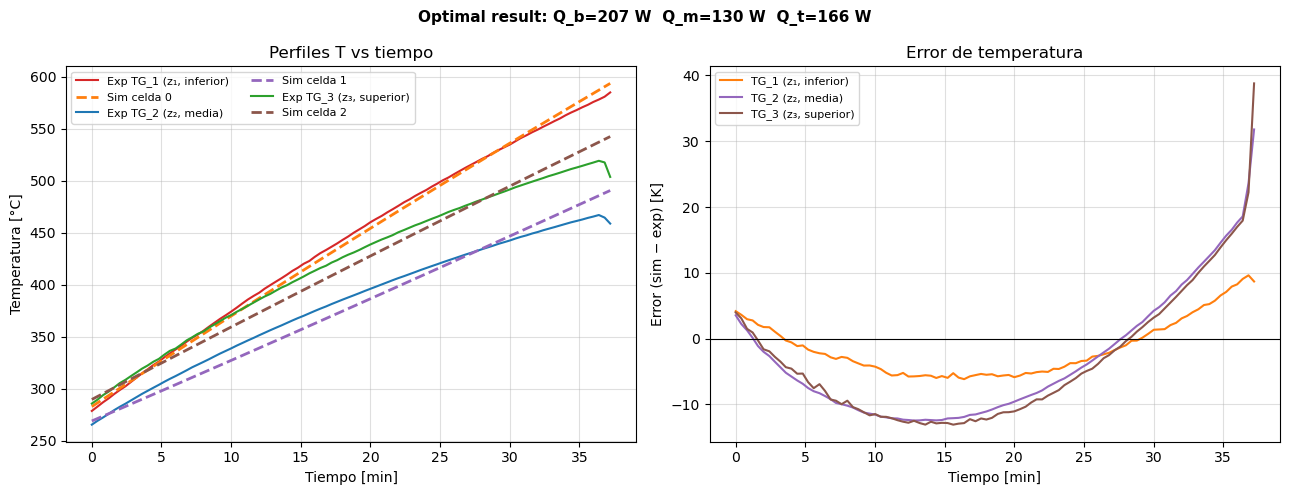

  RMSE zona 1 (TG_1): 4.51 K
  RMSE zona 2 (TG_2): 10.07 K
  RMSE zona 3 (TG_3): 10.42 K
  RMSE medio         : 8.34 K


In [11]:
# Simulation with optimal parameters
params_opt, sv0_opt = build_heater_params(Q_opt_b, Q_opt_m, Q_opt_t)

t_arr_opt, _, h_opt = run_step(
    sv0=sv0_opt, t_max=T_MAX_s, params=params_opt,
    solver="solve_ivp", rtol=RTOL, atol=ATOL, n_sec=N_SEC,
)

print("Comparison with optimal parameters:")
plot_comparison(
    h_opt, t_arr_opt,
    title=f"Optimal result: Q_b={Q_opt_b:.0f} W  Q_m={Q_opt_m:.0f} W  Q_t={Q_opt_t:.0f} W",
)

## 7. Balance de energía del calentador

Verificación de la conservación de energía en la simulación óptima.

In [12]:
df_bal = balance_report(h_opt, params_opt, include_energy=True, print_report=True)

──────────────────────────────────────────────────────────────────────────────────
  INFORME DE BALANCE DE CONSERVACIÓN — HEATER
──────────────────────────────────────────────────────────────────────────────────
               Acumulación  Flujo neto BC   Error abs  Error rel [%]
Variable                                                            
N_N2 [mol]     +8.9289e-18             +0 +8.9289e-18    +2.8229e-15
N_total [mol]  +8.9289e-18             +0 +8.9289e-18    +2.8229e-15
E_gas [kJ]        +0.65842       +0.65846 +4.0046e-05    +0.00061548
E_wall [kJ]        +1119.7        +1119.6   +0.070773     +0.0063207
E_sys [kJ]         +1120.4        +1120.3   -0.070732     -0.0063134
──────────────────────────────────────────────────────────────────────────────────
  Error máximo: 0.006 %  →  EXCELENTE  (<0.1 %)

  Desglose de términos energéticos [kJ]:
    Ein             = +5.118
    Eout            = +6.506
    Qcond_g_net     = -0.7446  (conducción gas en contornos)
    Qwall    

## 8. Análisis de sensibilidad

Exploración del espacio de parámetros alrededor de la solución óptima.

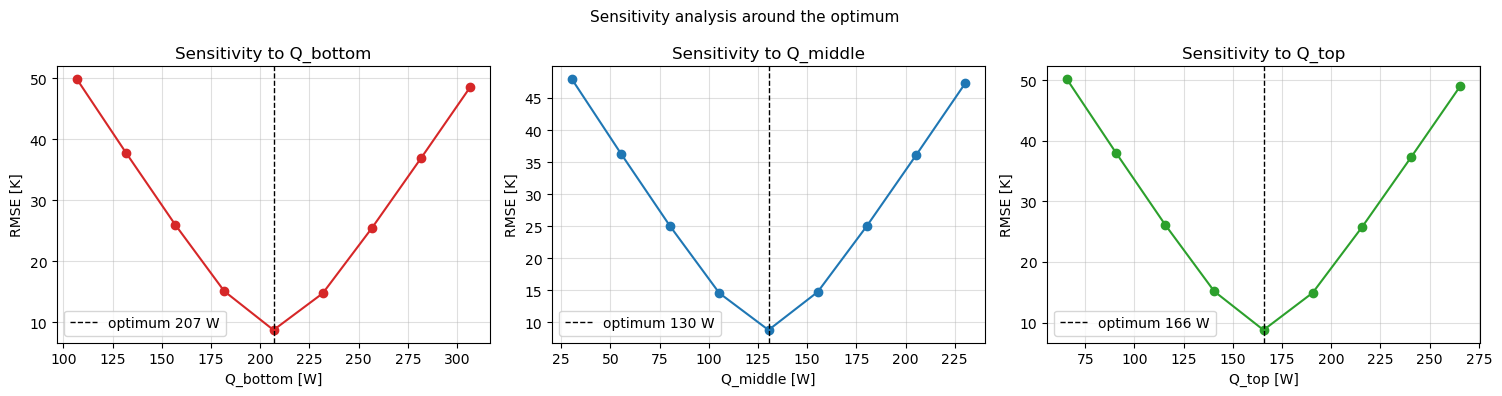

In [13]:
# 1-D sensitivity scan around the optimum for each free parameter
dQ     = 100.0   # variation range [W]
n_scan = 9

Q_b_scan = np.linspace(max(Q_opt_b - dQ, 0.0), Q_opt_b + dQ, n_scan)
Q_m_scan = np.linspace(max(Q_opt_m - dQ, 0.0), Q_opt_m + dQ, n_scan)
Q_t_scan = np.linspace(max(Q_opt_t - dQ, 0.0), Q_opt_t + dQ, n_scan)

_eval_count[0] = 0
rmse_b = [objective([qb, Q_opt_m, Q_opt_t]) for qb in Q_b_scan]
_eval_count[0] = 0
rmse_m = [objective([Q_opt_b, qm, Q_opt_t]) for qm in Q_m_scan]
_eval_count[0] = 0
rmse_t = [objective([Q_opt_b, Q_opt_m, qt]) for qt in Q_t_scan]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, scan, opt, rmse, label, clr in zip(
    axes,
    [Q_b_scan, Q_m_scan, Q_t_scan],
    [Q_opt_b,  Q_opt_m,  Q_opt_t],
    [rmse_b,   rmse_m,   rmse_t],
    ["Q_bottom", "Q_middle", "Q_top"],
    ["#d62728", "#1f77b4", "#2ca02c"],
):
    ax.plot(scan, rmse, "o-", color=clr)
    ax.axvline(opt, ls="--", color="k", lw=1.0, label=f"optimum {opt:.0f} W")
    ax.set_xlabel(f"{label} [W]")
    ax.set_ylabel("RMSE [K]")
    ax.set_title(f"Sensitivity to {label}")
    ax.grid(True, alpha=0.4)
    ax.legend()

fig.suptitle("Sensitivity analysis around the optimum", fontsize=11)
plt.tight_layout()
plt.show()

## 9. Resumen de resultados

In [14]:
print("=" * 62)
print("  SUMMARY — NIVARIA GASIFIER HEATER POWER IDENTIFICATION")
print("=" * 62)
print()
print(f"  Experimental case  : {case['file_name']}")
print(f"  Pre-flow duration  : {T_MAX_s/60:.2f} min")
print()
print("  Inferred heater powers (fit to wall temperature data):")
print(f"    Q_bottom resistor  (zone TG_1, cell 0) = {Q_opt_b:.1f} W")
print(f"    Q_middle resistor  (zone TG_2, cell 1) = {Q_opt_m:.1f} W")
print(f"    Q_top    resistor  (zone TG_3, cell 2) = {Q_opt_t:.1f} W")
print(f"    Q_total                                = {Q_opt_b + Q_opt_m + Q_opt_t:.1f} W")
print()
print("  Fit quality:")
tg_keys = ["TG_1", "TG_2", "TG_3"]
for i, key in enumerate(tg_keys):
    T_sim_i = np.interp(t_exp_s, t_arr_opt, h_opt._Tw_results[:, i])
    err   = T_sim_i - T_exp_K[key]
    valid = np.isfinite(err)
    rmse_i = float(np.sqrt(np.mean(err[valid]**2)))
    bias_i = float(np.mean(err[valid]))
    print(f"    RMSE {key}: {rmse_i:.2f} K   Bias: {bias_i:+.2f} K")
print()
print("  Analytical pre-estimate (compute_bed_zone_power):")
print(f"    Q_z1={Q_est['z1']:.1f} W   Q_z2={Q_est['z2']:.1f} W   Q_z3={Q_est['z3']:.1f} W")
print("=" * 62)

  SUMMARY — NIVARIA GASIFIER HEATER POWER IDENTIFICATION

  Experimental case  : 20260128_NIVARIA_prueba_15 sin cribar.xlsx
  Pre-flow duration  : 37.22 min

  Inferred heater powers (fit to wall temperature data):
    Q_bottom resistor  (zone TG_1, cell 0) = 206.7 W
    Q_middle resistor  (zone TG_2, cell 1) = 130.4 W
    Q_top    resistor  (zone TG_3, cell 2) = 165.6 W
    Q_total                                = 502.7 W

  Fit quality:
    RMSE TG_1: 4.51 K   Bias: -1.47 K
    RMSE TG_2: 10.07 K   Bias: -3.16 K
    RMSE TG_3: 10.42 K   Bias: -3.54 K

  Analytical pre-estimate (compute_bed_zone_power):
    Q_z1=179.8 W   Q_z2=118.5 W   Q_z3=138.4 W


## 10. Exportar resultados

In [15]:
import json, pathlib

_results_dir = pathlib.Path(EXP) / "results"
_results_dir.mkdir(exist_ok=True)

_out = {
    "source_case_idx":  CASE_IDX,
    "source_case_file": case["file_name"],
    "Q_bottom_W":       round(Q_opt_b, 2),
    "Q_middle_W":       round(Q_opt_m, 2),
    "Q_top_W":          round(Q_opt_t, 2),
    "Q_total_W":        round(Q_opt_b + Q_opt_m + Q_opt_t, 2),
    "RMSE_K":           round(float(result_opt.fun), 4),
    "n_evaluations":    _eval_count[0],
}

_path = _results_dir / "step1_heater_powers.json"
with open(_path, "w") as f:
    json.dump(_out, f, indent=2)

print(f"Saved to: {_path}")
print(json.dumps(_out, indent=2))

Saved to: C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\HEATER\experimentacion\results\step1_heater_powers.json
{
  "source_case_idx": 2,
  "source_case_file": "20260128_NIVARIA_prueba_15 sin cribar.xlsx",
  "Q_bottom_W": 206.73,
  "Q_middle_W": 130.35,
  "Q_top_W": 165.57,
  "Q_total_W": 502.65,
  "RMSE_K": 8.7648,
  "n_evaluations": 9
}
